# Universidade Federal da Paraíba

# Centro de Informática - Departamento de Informática


**Disciplina**: Aprendizado Profundo


**Período**: 2025.2


**Professor**: Tiago Maritan


# Atividade: Lista de Exercícios

**Equipe**:

Renan Gondim Dias de Albuquerque - 20220070645

Victor Marques de Sousa - 20220055863

Pedro Augusto Amorim Figueiredo de Melo - 20220062545

---
# **Questão 4**
*Objetivo: Compreender a compressão e reconstrução de dados utilizando Autoencoders com Fashion-MNIST.*



## 4.a) Autoencoder Tradicional
*(Treinamento, gráficos de perda e visualização das 10 reconstruções)*

### 1. Importação das Bibliotecas

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

### 2. Carregamento e Pré-processamento dos Dados

In [3]:
# O Keras já possui o Fashion-MNIST embutido, facilitando o processo do Kaggle
(x_train, _), (x_test, _) = fashion_mnist.load_data()

# Normalizando os pixels para valores entre 0 e 1 (facilita o treinamento)
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Como usaremos camadas Densas, precisamos achatar (flatten) as imagens 28x28 para vetores de 784 posições
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


### 3. Construção do Autoencoder

In [4]:
entrada = Input(shape=(784,))

# Encoder (comprimindo de 784 para 128, e depois para 64)
encoded = Dense(128, activation='relu')(entrada)
encoded = Dense(64, activation='relu')(encoded) # Esse é o nosso espaço latente

# Decoder (descomprimindo de 64 para 128, e de volta para 784)
decoded = Dense(128, activation='relu')(encoded)
saida = Dense(784, activation='sigmoid')(decoded) # Sigmoid pois os pixels estão entre 0 e 1

# Juntando tudo no modelo
autoencoder = Model(entrada, saida)

# Compilando o modelo com o otimizador Adam e a função de custo de Erro Quadrático Médio (MSE)
autoencoder.compile(optimizer='adam', loss='mse')

### 4. Treinamento

In [5]:
# Note que passamos x_train tanto como entrada quanto como "gabarito" (y)
historico = autoencoder.fit(x_train, x_train,
                            epochs=50,
                            batch_size=256,
                            shuffle=True,
                            validation_data=(x_test, x_test))

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0727 - val_loss: 0.0226
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0212 - val_loss: 0.0180
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0175 - val_loss: 0.0162
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0157 - val_loss: 0.0148
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0145 - val_loss: 0.0140
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0137 - val_loss: 0.0134
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0131 - val_loss: 0.0126
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0125 - val_loss: 0.0123
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0121 - val_loss: 0.0118
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0117 - val_loss: 0.0115
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0114 - val_loss: 0.0112
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 

### 5. Apresentando a Curva de Erro

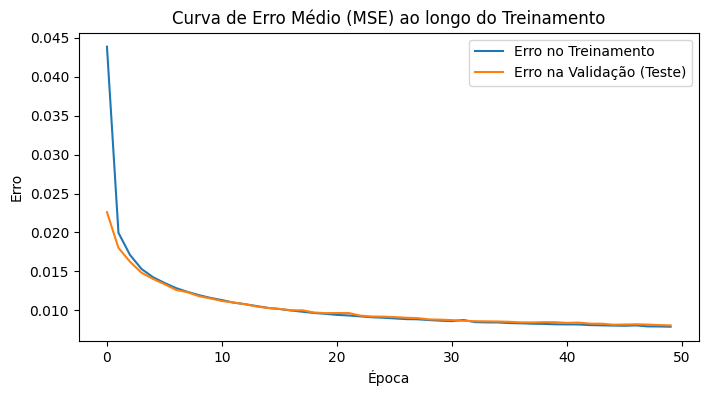

In [6]:
plt.figure(figsize=(8, 4))
plt.plot(historico.history['loss'], label='Erro no Treinamento')
plt.plot(historico.history['val_loss'], label='Erro na Validação (Teste)')
plt.title('Curva de Erro Médio (MSE) ao longo do Treinamento')
plt.ylabel('Erro')
plt.xlabel('Época')
plt.legend()
plt.show()

### 6. Visualização Lado a Lado (Original vs Reconstrução)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step


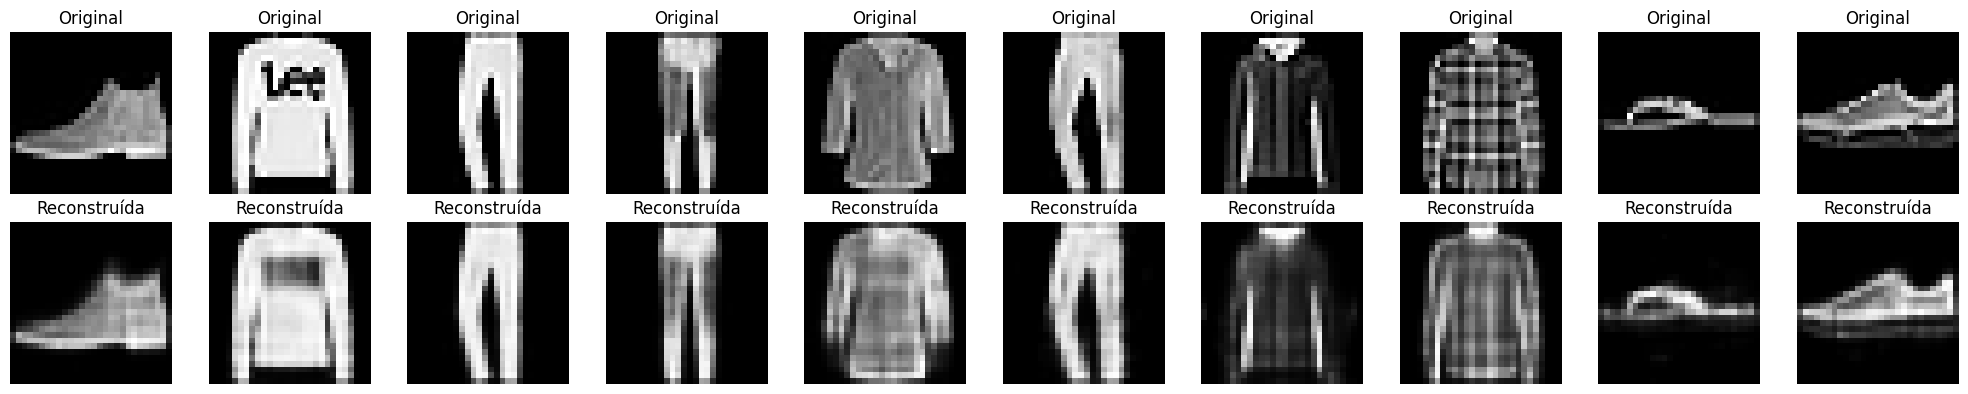

In [7]:
# 5. Visualização Lado a Lado (Original vs Reconstrução)
# Selecionando 10 imagens do conjunto de teste
num_imagens = 10
imagens_selecionadas = x_test[:num_imagens]

# Gerando as reconstruções
reconstrucoes = autoencoder.predict(imagens_selecionadas)

# Plotando
plt.figure(figsize=(20, 4))
for i in range(num_imagens):
    # Imagem Original
    ax = plt.subplot(2, num_imagens, i + 1)
    plt.imshow(imagens_selecionadas[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Imagem Reconstruída
    ax = plt.subplot(2, num_imagens, i + 1 + num_imagens)
    plt.imshow(reconstrucoes[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstruída")
    plt.axis('off')

plt.tight_layout()
plt.show()

## 4.b) Denoising Autoencoder (Remoção de Ruído)
*(Adição de ruído aleatório, treinamento e avaliação visual comparativa)*

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.0768 - val_loss: 0.0254
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0237 - val_loss: 0.0209
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0198 - val_loss: 0.0183
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.0179 - val_loss: 0.0170
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0168 - val_loss: 0.0162
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0160 - val_loss: 0.0155
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0153 - val_loss: 0.0155
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0150 - val_loss: 0.0148
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0144 - val_loss: 0.0143
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0141 - val_loss: 0.0140
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0138 - val_loss: 0.0138
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 

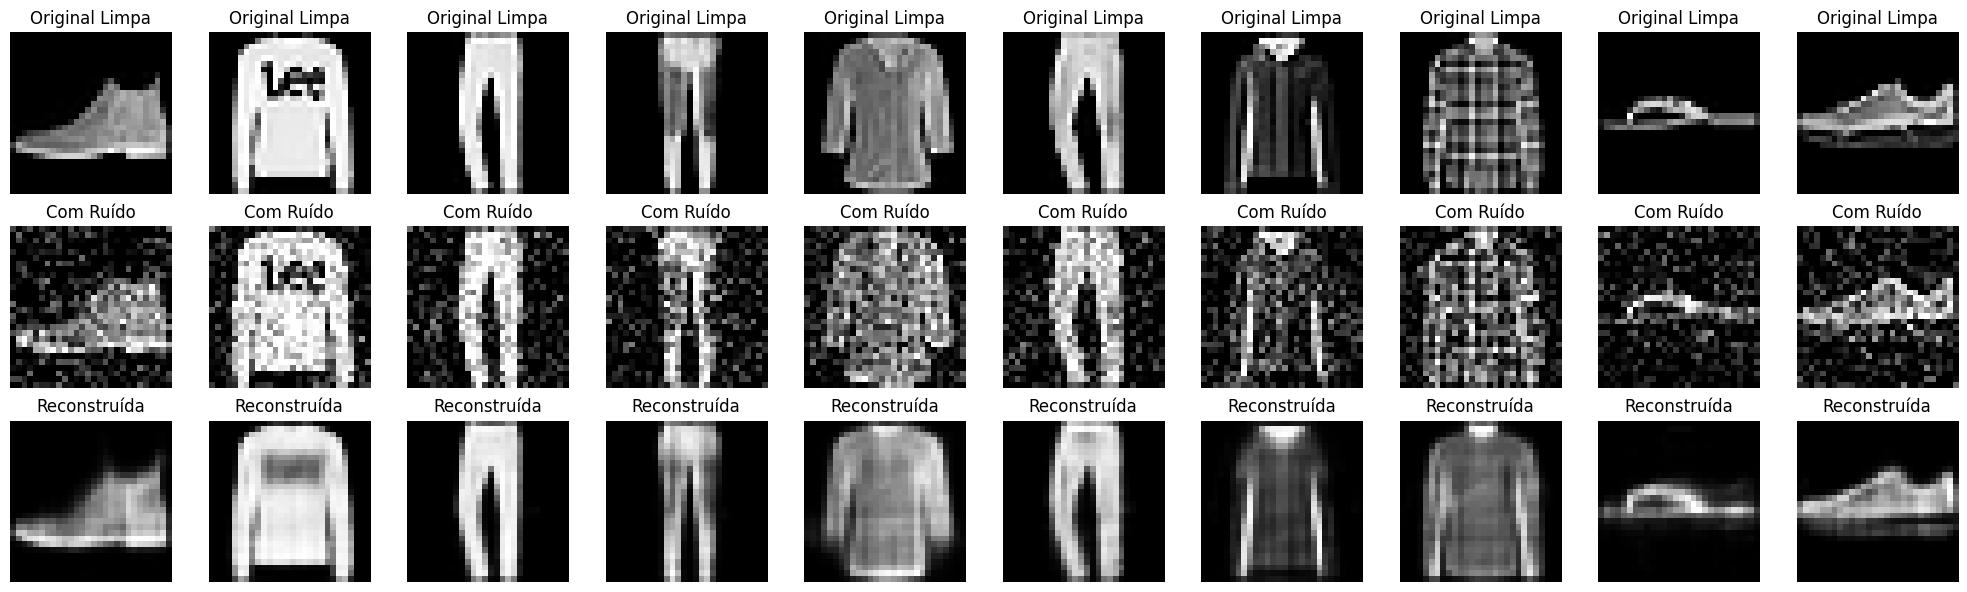

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# 1. Carregamento, Pré-processamento e Achatar
(x_train, _), (x_test, _) = fashion_mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

# 2. Adicionando ruído
fator_ruido = 0.2 # Intensidade do chuvisco

x_train_noisy = x_train + fator_ruido * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + fator_ruido * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# Como o ruído pode fazer os pixels passarem de 1 ou ficarem menores que 0,
# usamos o clip para forçar tudo a ficar entre 0 e 1 novamente.
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# 3. Construção do Autoencoder (Mesma arquitetura)
entrada = Input(shape=(784,))
encoded = Dense(128, activation='relu')(entrada)
encoded = Dense(64, activation='relu')(encoded)
decoded = Dense(128, activation='relu')(encoded)
saida = Dense(784, activation='sigmoid')(decoded)

autoencoder_denoising = Model(entrada, saida)
autoencoder_denoising.compile(optimizer='adam', loss='mse')

# 4. Treinamento (Atenção para o x_train_noisy vs x_train)
# Entra a imagem COM ruído, o gabarito é a imagem SEM ruído!
historico_denoising = autoencoder_denoising.fit(x_train_noisy, x_train,
                            epochs=50,
                            batch_size=256,
                            shuffle=True,
                            validation_data=(x_test_noisy, x_test))

# 5. Visualização (Original vs Ruidosa vs Reconstruída)
num_imagens = 10
imagens_originais = x_test[:num_imagens]
imagens_ruidosas = x_test_noisy[:num_imagens]

# Pedimos para a rede limpar as imagens ruidosas
reconstrucoes = autoencoder_denoising.predict(imagens_ruidosas)

plt.figure(figsize=(20, 6))
for i in range(num_imagens):
    # Imagem Original
    ax = plt.subplot(3, num_imagens, i + 1)
    plt.imshow(imagens_originais[i].reshape(28, 28), cmap='gray')
    plt.title("Original Limpa")
    plt.axis('off')

    # Imagem Ruidosa (Entrada do modelo)
    ax = plt.subplot(3, num_imagens, i + 1 + num_imagens)
    plt.imshow(imagens_ruidosas[i].reshape(28, 28), cmap='gray')
    plt.title("Com Ruído")
    plt.axis('off')

    # Imagem Reconstruída (Saída do modelo)
    ax = plt.subplot(3, num_imagens, i + 1 + 2 * num_imagens)
    plt.imshow(reconstrucoes[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstruída")
    plt.axis('off')

plt.tight_layout()
plt.show()